# Olist E-Commerce Analytics — EDA & Business KPIs
### Python / Pandas / Matplotlib Analysis

**Author:** *(Md Farhan)*
**Dataset:** Olist Brazilian E-Commerce Public Dataset (7 CSVs — customers, orders, order_items,
payments, products, sellers, geolocation)

**Goal:** Clean, merge, and analyze the transactional data to answer core business questions
about revenue, category/seller performance, payment behavior, and customer trends — the Python
counterpart to the SQL analysis in this project.

**Notebook sections:**
1. Setup & Imports
2. Load Data
3. Initial Exploration
4. Data Quality Assessment
5. Data Cleaning
6. Merging into a Master Analytical Table
7. Feature Engineering
8. Business KPIs
9. Visualizations (10 charts)
10. Key Insights & Recommendations


## 1. Setup & Imports

In [ ]:
# Core libraries for this analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Display settings — show more columns/rows while exploring, avoid truncated output
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)

# Consistent, professional chart styling used throughout the notebook
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 10

print("Libraries loaded:", pd.__version__, np.__version__)


Libraries loaded: 2.2.2 2.0.2


## 2. Load Data

**If running in Google Colab:** run the upload cell below and select all 7 CSVs when prompted.

**If running locally:** place the CSVs in the same folder as this notebook (or edit `DATA_DIR`)
and skip the upload cell.

Expected filenames (rename your files to match, or edit the `FILES` dict below):
`customers_csv.csv`, `geolocation_csv.csv`, `order_items_csv.csv`, `orders_csv.csv`,
`payments_csv.csv`, `products_csv.csv`, `sellers_csv.csv`


In [ ]:
DATA_DIR = "."  # <-- edit this if your CSVs live in a different folder

FILES = {
    "customers":    "/content/customers.csv.csv",
    "geolocation":  "/content/geolocation.csv.csv",
    "order_items":  "/content/order_items.csv.csv",
    "orders":       "/content/orders.csv.csv",
    "payments":     "/content/payments.csv.csv",
    "products":     "/content/products.csv.csv",
    "sellers":      "/content/sellers.csv.csv",
}

import os
customers   = pd.read_csv(os.path.join(DATA_DIR, FILES["customers"])) # Corrected key
geolocation = pd.read_csv(os.path.join(DATA_DIR, FILES["geolocation"]))
order_items = pd.read_csv(os.path.join(DATA_DIR, FILES["order_items"]))
orders      = pd.read_csv(os.path.join(DATA_DIR, FILES["orders"]))
payments    = pd.read_csv(os.path.join(DATA_DIR, FILES["payments"]))
products    = pd.read_csv(os.path.join(DATA_DIR, FILES["products"]))
sellers     = pd.read_csv(os.path.join(DATA_DIR, FILES["sellers"]))

print("All files loaded.")
for name, df in [("customers", customers), ("orders", orders), ("order_items", order_items),
                  ("payments", payments), ("products", products), ("sellers", sellers),
                  ("geolocation", geolocation)]:
    print(f"  {name:12s} -> {df.shape}")

All files loaded.
  customers    -> (99441, 5)
  orders       -> (99441, 8)
  order_items  -> (112650, 7)
  payments     -> (103886, 5)
  products     -> (32951, 9)
  sellers      -> (3095, 4)
  geolocation  -> (1000163, 5)


## 3. Initial Exploration\n\nLook at structure and datatypes before touching anything.

In [ ]:
for name, df in [("customers", customers), ("orders", orders), ("order_items", order_items),
                  ("payments", payments), ("products", products), ("sellers", sellers),
                  ("geolocation", geolocation)]:
    print(f"\n{'='*60}\n{name.upper()}\n{'='*60}")
    print(df.dtypes)
    print(df.head(2))



CUSTOMERS
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
                        customer_id                customer_unique_id  customer_zip_code_prefix          customer_city customer_state
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0                     14409                 franca             SP
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3                      9790  sao bernardo do campo             SP

ORDERS
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object
                           order_id                     

## 4. Data Quality Assessment

Checking systematically for nulls, duplicates, and known issues before cleaning — this mirrors
the SQL validation queries (Deliverable 5) so both halves of the project agree on what's "dirty".


In [ ]:
print("NULL COUNTS PER TABLE\n")
for name, df in [("customers", customers), ("orders", orders), ("order_items", order_items),
                  ("payments", payments), ("products", products), ("sellers", sellers),
                  ("geolocation", geolocation)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f"{name}:\n{nulls}\n")
    else:
        print(f"{name}: no nulls\n")


NULL COUNTS PER TABLE

customers: no nulls

orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

order_items: no nulls

payments: no nulls

products:
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

sellers: no nulls

geolocation: no nulls



In [ ]:
print("DUPLICATE ROWS PER TABLE\n")
for name, df in [("customers", customers), ("orders", orders), ("order_items", order_items),
                  ("payments", payments), ("products", products), ("sellers", sellers),
                  ("geolocation", geolocation)]:
    print(f"{name}: {df.duplicated().sum():,} duplicate rows")

# geolocation has ~262K duplicate rows (repeated GPS pings per zip prefix) — confirmed here,
# handled in the cleaning step below.


DUPLICATE ROWS PER TABLE

customers: 0 duplicate rows
orders: 0 duplicate rows
order_items: 0 duplicate rows
payments: 0 duplicate rows
products: 0 duplicate rows
sellers: 0 duplicate rows
geolocation: 261,831 duplicate rows


In [ ]:
# Orphan-record check: order_items referencing products/sellers/orders that don't exist,
# and orders referencing customers that don't exist. Should all be zero on clean source data,
# but we verify rather than assume.
orphan_products = order_items.loc[~order_items['product_id'].isin(products['product_id'])]
orphan_sellers  = order_items.loc[~order_items['seller_id'].isin(sellers['seller_id'])]
orphan_orders   = order_items.loc[~order_items['order_id'].isin(orders['order_id'])]
orphan_customers = orders.loc[~orders['customer_id'].isin(customers['customer_id'])]

print("Orphan order_items -> missing product:", len(orphan_products))
print("Orphan order_items -> missing seller:", len(orphan_sellers))
print("Orphan order_items -> missing order:", len(orphan_orders))
print("Orphan orders -> missing customer:", len(orphan_customers))


Orphan order_items -> missing product: 0
Orphan order_items -> missing seller: 0
Orphan order_items -> missing order: 0
Orphan orders -> missing customer: 0


In [ ]:
# Negative or zero price / freight check — invalid for a real transaction
print("Order items with price <= 0:", (order_items['price'] <= 0).sum())
print("Order items with freight_value < 0:", (order_items['freight_value'] < 0).sum())
print("Payments with payment_value <= 0:", (payments['payment_value'] <= 0).sum())


Order items with price <= 0: 0
Order items with freight_value < 0: 0
Payments with payment_value <= 0: 9


## 5. Data Cleaning

Applying fixes for every issue confirmed above. Each step is commented with *why*, not just *what*.


In [ ]:
# 5.1 Fix the product category column name (source has a literal space: "product category")
products = products.rename(columns={"product category": "product_category"})

# 5.2 Deduplicate geolocation: collapse to one row per zip prefix using the mean lat/lng.
# Without this, joining geolocation to customers/sellers would fan out rows and silently
# inflate every downstream count.
geolocation_clean = (
    geolocation
    .groupby("geolocation_zip_code_prefix", as_index=False)
    .agg(
        geolocation_lat=("geolocation_lat", "mean"),
        geolocation_lng=("geolocation_lng", "mean"),
        geolocation_city=("geolocation_city", "first"),
        geolocation_state=("geolocation_state", "first"),
    )
)
print("geolocation:", geolocation.shape, "-> deduplicated:", geolocation_clean.shape)

# 5.3 Convert all timestamp columns to real datetimes
timestamp_cols = ["order_purchase_timestamp", "order_approved_at",
                   "order_delivered_carrier_date", "order_delivered_customer_date",
                   "order_estimated_delivery_date"]
for col in timestamp_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"], errors="coerce")

# 5.4 Nulls in delivery timestamp columns are NOT errors — they represent orders that were
# canceled/never completed. We keep them as NaT (do not fill/impute) so delivery-time
# calculations correctly exclude incomplete orders rather than fabricating dates.
print("\nRemaining nulls in orders after conversion (expected — incomplete orders):")
print(orders[timestamp_cols].isnull().sum())

# 5.5 Missing product_category (610 rows) — flag explicitly rather than silently dropping,
# since dropping would also drop the associated sales from category-level analysis.
products["product_category"] = products["product_category"].fillna("unknown")
print("\nProducts with unknown category after fill:", (products['product_category'] == 'unknown').sum())


geolocation: (1000163, 5) -> deduplicated: (19015, 5)

Remaining nulls in orders after conversion (expected — incomplete orders):
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Products with unknown category after fill: 610


## 6. Merging into a Master Analytical Table

Building one denormalized table at the **order-item grain** (one row per product sold), since
that's the finest grain needed for revenue analysis. We aggregate up from here as needed.


In [ ]:
master = (
    order_items
    .merge(orders, on="order_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(sellers, on="seller_id", how="left")
)

print("Master table shape:", master.shape)
assert len(master) == len(order_items), "Row count changed during merge — check for fan-out joins"
master.head(3)


Master table shape: (112650, 29)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,Cool Stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet Shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,Furniture Decoration,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,37564,borda da mata,MG


In [ ]:
# Payments merge separately: payments are at order grain, not order-item grain (multiple
# payment rows can exist per order via installments/split payment methods), so merging directly
# onto the item-grain master would double-count revenue. We aggregate first.
payments_per_order = payments.groupby("order_id", as_index=False).agg(
    total_payment_value=("payment_value", "sum"),
    payment_installments_max=("payment_installments", "max"),
    n_payment_methods=("payment_type", "nunique"),
)
payment_type_per_order = (
    payments.sort_values("payment_value", ascending=False)
    .drop_duplicates("order_id")[["order_id", "payment_type"]]
    .rename(columns={"payment_type": "primary_payment_type"})
)
payments_per_order = payments_per_order.merge(payment_type_per_order, on="order_id", how="left")

print("payments_per_order shape:", payments_per_order.shape, "(should equal unique orders in payments:",
      payments['order_id'].nunique(), ")")
payments_per_order.head(3)


payments_per_order shape: (99440, 5) (should equal unique orders in payments: 99440 )


,order_id,total_payment_value,payment_installments_max,n_payment_methods,primary_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card


## 7. Feature Engineering

In [ ]:
# Revenue per line item (price is item revenue; freight is a pass-through cost, kept separate)
master["item_revenue"] = master["price"]

# Time-based features for trend analysis
master["order_year"] = master["order_purchase_timestamp"].dt.year
master["order_month"] = master["order_purchase_timestamp"].dt.month
master["order_year_month"] = master["order_purchase_timestamp"].dt.to_period("M")

# Delivery performance: only computable for delivered orders (others are NaT by design)
master["delivery_days"] = (
    master["order_delivered_customer_date"] - master["order_purchase_timestamp"]
).dt.days

# Was delivery late vs. the estimate? (only meaningful where actually delivered)
master["delivered_late"] = (
    master["order_delivered_customer_date"] > master["order_estimated_delivery_date"]
)

master[["order_purchase_timestamp", "order_year_month", "delivery_days", "delivered_late"]].head(3)


,order_purchase_timestamp,order_year_month,delivery_days,delivered_late
0,2017-09-13 08:59:02,2017-09,7.0,False
1,2017-04-26 10:53:06,2017-04,16.0,False
2,2018-01-14 14:33:31,2018-01,7.0,False


## 8. Business KPIs

Headline numbers first — these are the figures that would go directly into an executive summary.


In [ ]:
total_revenue = master["item_revenue"].sum()
total_orders = master["order_id"].nunique()
aov = total_revenue / total_orders
n_customers = master["customer_unique_id"].nunique()
n_sellers = master["seller_id"].nunique()
n_categories = master["product_category"].nunique()

print(f"Total Revenue:            R$ {total_revenue:,.2f}")
print(f"Total Orders:             {total_orders:,}")
print(f"Average Order Value:      R$ {aov:,.2f}")
print(f"Unique Customers:         {n_customers:,}")
print(f"Active Sellers:           {n_sellers:,}")
print(f"Product Categories:       {n_categories}")


Total Revenue:            R$ 13,591,643.70
Total Orders:             98,666
Average Order Value:      R$ 137.75
Unique Customers:         95,420
Active Sellers:           3,095
Product Categories:       74


In [ ]:
# % of orders paid in installments (>1) — ties back to SQL Basic Q4
orders_with_payment = orders.merge(payments_per_order, on="order_id", how="left")
pct_installments = (orders_with_payment["payment_installments_max"] > 1).mean() * 100
print(f"% of orders paid in installments: {pct_installments:.2f}%")


% of orders paid in installments: 51.46%


In [ ]:
# Revenue by category — top 10
revenue_by_category = (
    master.groupby("product_category")["item_revenue"]
    .sum()
    .sort_values(ascending=False)
)
print("Top 10 categories by revenue:")
revenue_by_category.head(10)


Top 10 categories by revenue:


,item_revenue
product_category,
HEALTH BEAUTY,1258681.34
Watches present,1205005.68
bed table bath,1036988.68
sport leisure,988048.97
computer accessories,911954.32
Furniture Decoration,729762.49
Cool Stuff,635290.85
housewares,632248.66
automotive,592720.11


In [ ]:
# Seller revenue ranking — top 10
revenue_by_seller = (
    master.groupby("seller_id")["item_revenue"]
    .sum()
    .sort_values(ascending=False)
)
print("Top 10 sellers by revenue:")
revenue_by_seller.head(10)


Top 10 sellers by revenue:


,item_revenue
seller_id,
4869f7a5dfa277a7dca6462dcf3b52b2,229472.63
53243585a1d6dc2643021fd1853d8905,222776.05
4a3ca9315b744ce9f8e9374361493884,200472.92
fa1c13f2614d7b5c4749cbc52fecda94,194042.03
7c67e1448b00f6e969d365cea6b010ab,187923.89
7e93a43ef30c4f03f38b393420bc753a,176431.87
da8622b14eb17ae2831f4ac5b9dab84a,160236.57
7a67c85e85bb2ce8582c35f2203ad736,141745.53
1025f0e2d44d7041d6cf58b6550e0bfa,138968.55


## 9. Visualizations

Ten charts covering the core business questions. Each includes a one-line business insight.


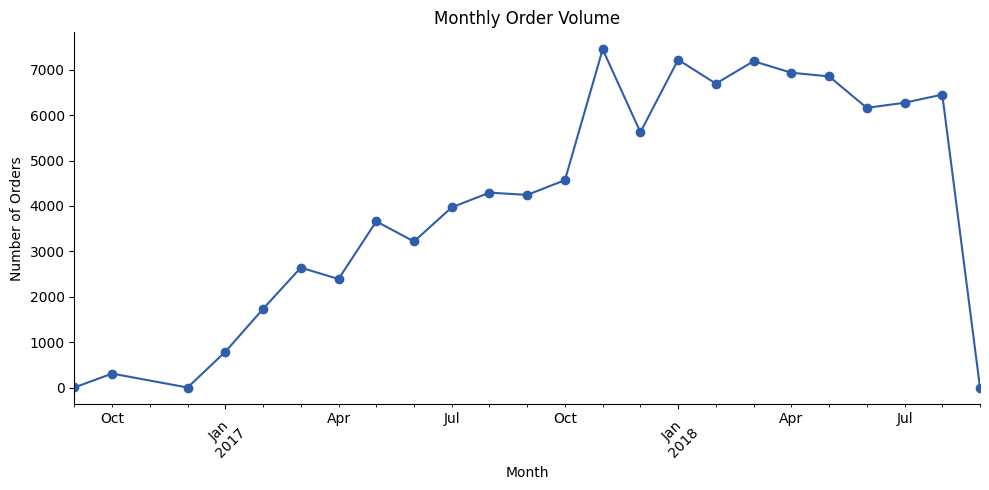

In [ ]:
# --- Chart 1: Monthly Order Volume ---
monthly_orders = master.drop_duplicates("order_id").groupby("order_year_month").size()

fig, ax = plt.subplots()
monthly_orders.plot(kind="line", marker="o", ax=ax, color="#2E5EAA")
ax.set_title("Monthly Order Volume")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight: order volume shows the overall growth/decline trajectory of the marketplace month
# over month — a sudden drop at the very end of the series is usually a partial/incomplete
# final month in the data, not a real business decline. Check the max date before concluding.


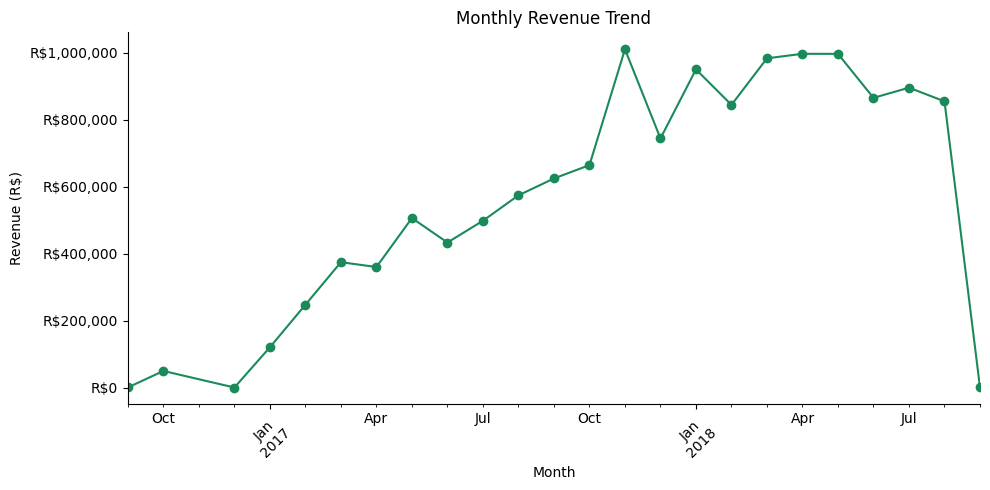

In [ ]:
# --- Chart 2: Monthly Revenue Trend ---
monthly_revenue = master.groupby("order_year_month")["item_revenue"].sum()

fig, ax = plt.subplots()
monthly_revenue.plot(kind="line", marker="o", ax=ax, color="#1B8A5A")
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight: compare shape of this curve to Chart 1 (order volume) — if revenue grows faster than
# order count, AOV is increasing (upsell/higher-value baskets); if slower, AOV is eroding.


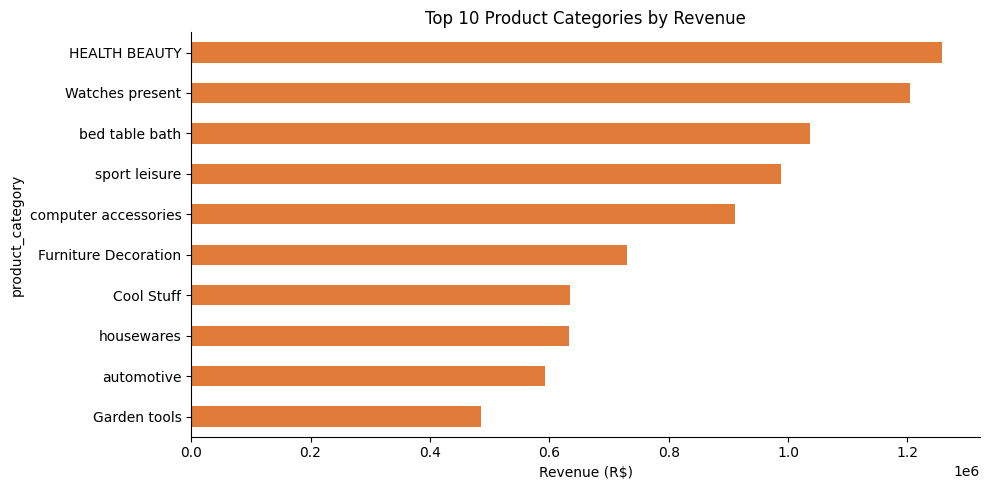

In [ ]:
# --- Chart 3: Top 10 Categories by Revenue ---
top_categories = revenue_by_category.head(10)

fig, ax = plt.subplots()
top_categories.sort_values().plot(kind="barh", ax=ax, color="#E07B39")
ax.set_title("Top 10 Product Categories by Revenue")
ax.set_xlabel("Revenue (R$)")
plt.tight_layout()
plt.show()

# Insight: these categories are the marketplace's core revenue drivers — prioritize them for
# inventory depth, seller recruitment, and promotional placement.


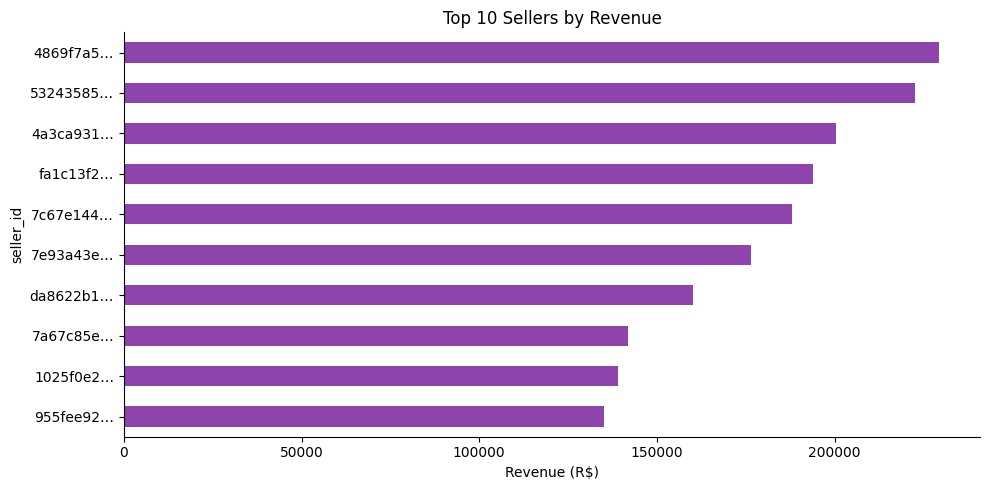

In [ ]:
# --- Chart 4: Top 10 Sellers by Revenue ---
top_sellers = revenue_by_seller.head(10)

fig, ax = plt.subplots()
top_sellers.sort_values().plot(kind="barh", ax=ax, color="#8E44AD")
ax.set_title("Top 10 Sellers by Revenue")
ax.set_xlabel("Revenue (R$)")
ax.set_yticklabels([s[:8] + "…" for s in top_sellers.sort_values().index])
plt.tight_layout()
plt.show()

# Insight: a small number of sellers concentrating a large share of revenue is a supply-side
# concentration risk — worth checking what % of total revenue the top 10 represent.


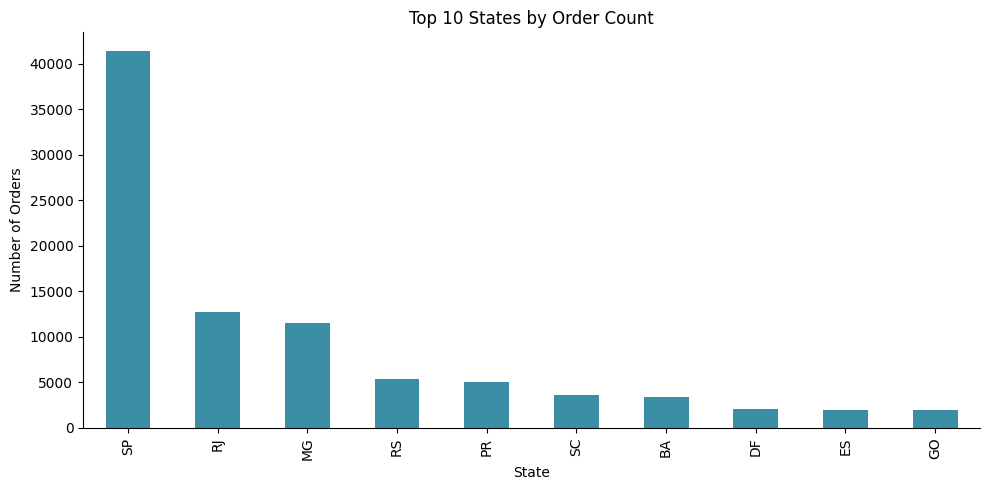

In [ ]:
# --- Chart 5: Orders by Customer State ---
orders_by_state = master.drop_duplicates("order_id").groupby("customer_state").size().sort_values(ascending=False)

fig, ax = plt.subplots()
orders_by_state.head(10).plot(kind="bar", ax=ax, color="#3B8EA5")
ax.set_title("Top 10 States by Order Count")
ax.set_xlabel("State")
ax.set_ylabel("Number of Orders")
plt.tight_layout()
plt.show()

# Insight: demand is concentrated where population/e-commerce penetration is highest (typically
# SP) — useful for regional marketing budget allocation and logistics network planning.


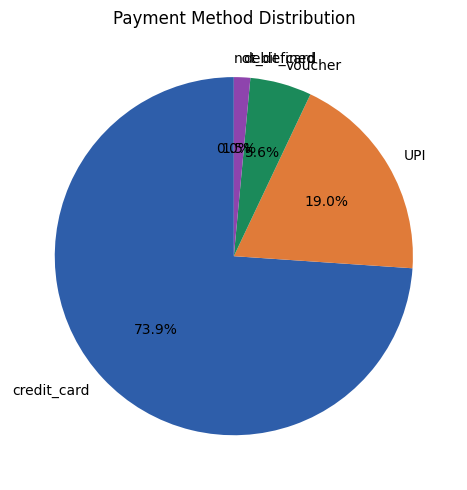

In [ ]:
# --- Chart 6: Payment Type Distribution ---
payment_type_dist = payments["payment_type"].value_counts()

fig, ax = plt.subplots()
payment_type_dist.plot(kind="pie", ax=ax, autopct="%1.1f%%", startangle=90,
                        colors=["#2E5EAA", "#E07B39", "#1B8A5A", "#8E44AD", "#B0B0B0"])
ax.set_ylabel("")
ax.set_title("Payment Method Distribution")
plt.tight_layout()
plt.show()

# Insight: if credit card + installments dominates, customers are financing purchases —
# relevant to cash-flow planning and potential BNPL partnership opportunities.


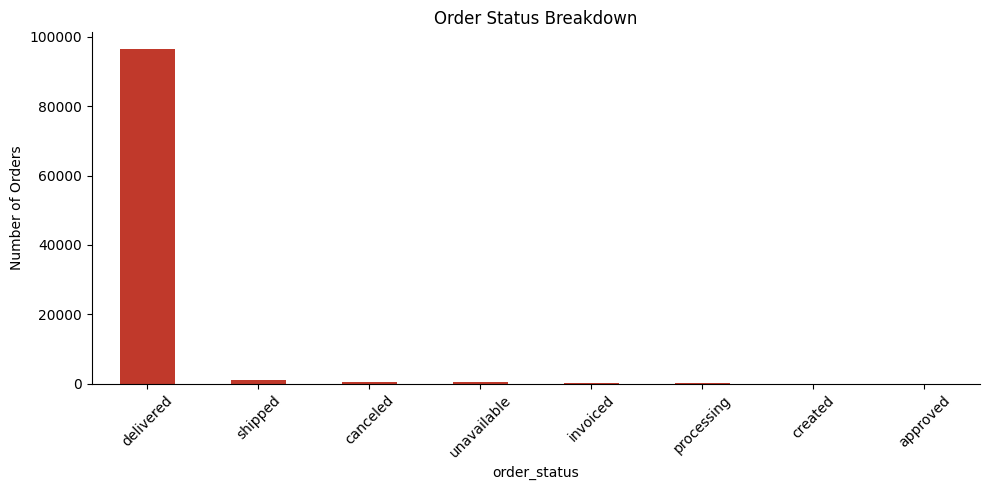

In [ ]:
# --- Chart 7: Order Status Breakdown ---
status_dist = orders["order_status"].value_counts()

fig, ax = plt.subplots()
status_dist.plot(kind="bar", ax=ax, color="#C0392B")
ax.set_title("Order Status Breakdown")
ax.set_ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight: a high 'canceled' or 'unavailable' share directly represents lost revenue and
# potential fulfillment/inventory problems worth investigating with Ops.


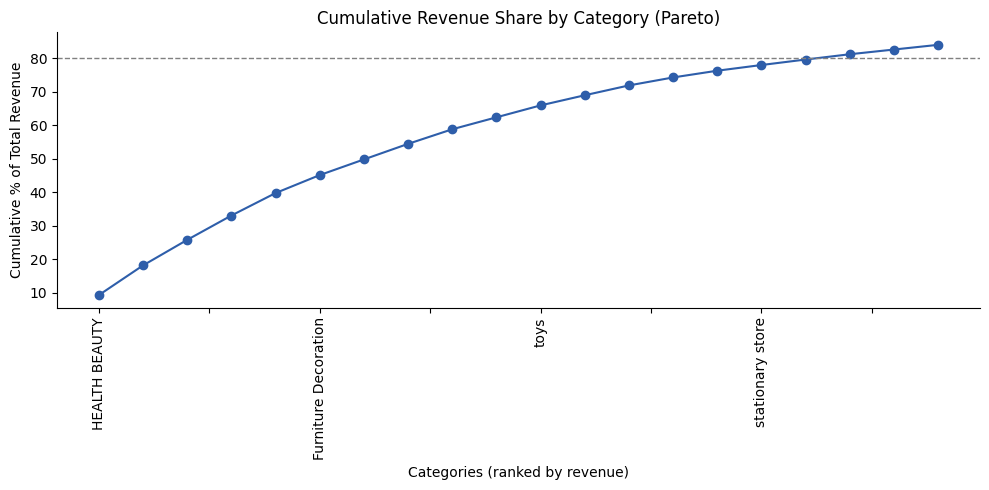

In [ ]:
# --- Chart 8: Revenue Concentration (Pareto) — Top Categories' Cumulative Share ---
cum_share = (revenue_by_category / total_revenue * 100).cumsum()

fig, ax = plt.subplots()
cum_share.head(20).plot(kind="line", marker="o", ax=ax, color="#2E5EAA")
ax.axhline(80, color="gray", linestyle="--", linewidth=1)
ax.set_title("Cumulative Revenue Share by Category (Pareto)")
ax.set_xlabel("Categories (ranked by revenue)")
ax.set_ylabel("Cumulative % of Total Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Insight: shows how many categories are needed to reach 80% of revenue — a classic
# Pareto/concentration check. Few categories driving most revenue = concentration risk;
# many needed = a healthy, diversified catalog.


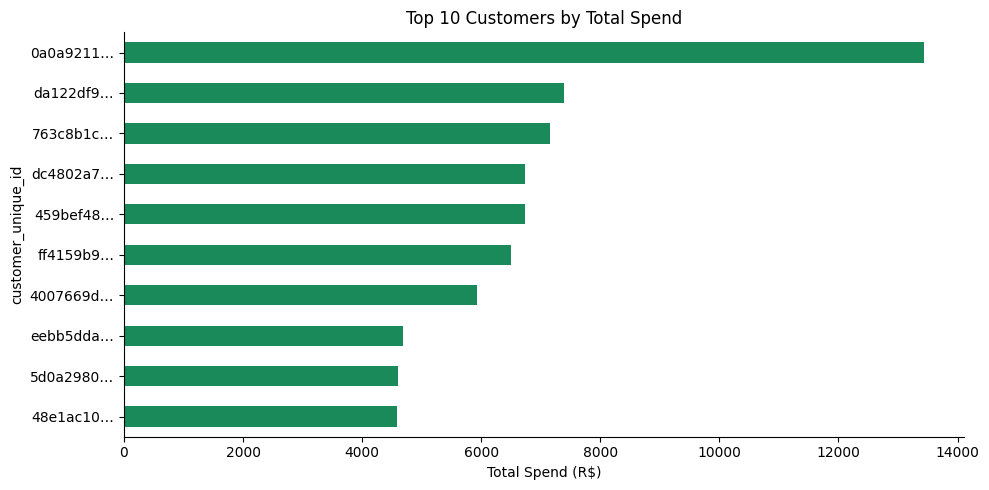

In [ ]:
# --- Chart 9: Top 10 Customers by Lifetime Spend ---
# Using customer_unique_id (the PERSON), not customer_id (the order), per the schema note
# in Deliverable 2 — otherwise repeat customers would be undercounted.
top_customers = (
    master.groupby("customer_unique_id")["item_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots()
top_customers.sort_values().plot(kind="barh", ax=ax, color="#1B8A5A")
ax.set_yticklabels([c[:8] + "…" for c in top_customers.sort_values().index])
ax.set_title("Top 10 Customers by Total Spend")
ax.set_xlabel("Total Spend (R$)")
plt.tight_layout()
plt.show()

# Insight: these are candidates for a VIP/loyalty program — protecting high-LTV relationships
# is usually cheaper than acquiring new customers of equivalent value.


/tmp/ipykernel_2130/2836020265.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: master.loc[master['order_id'].isin(g['order_id']), 'item_revenue'].sum() / len(g))


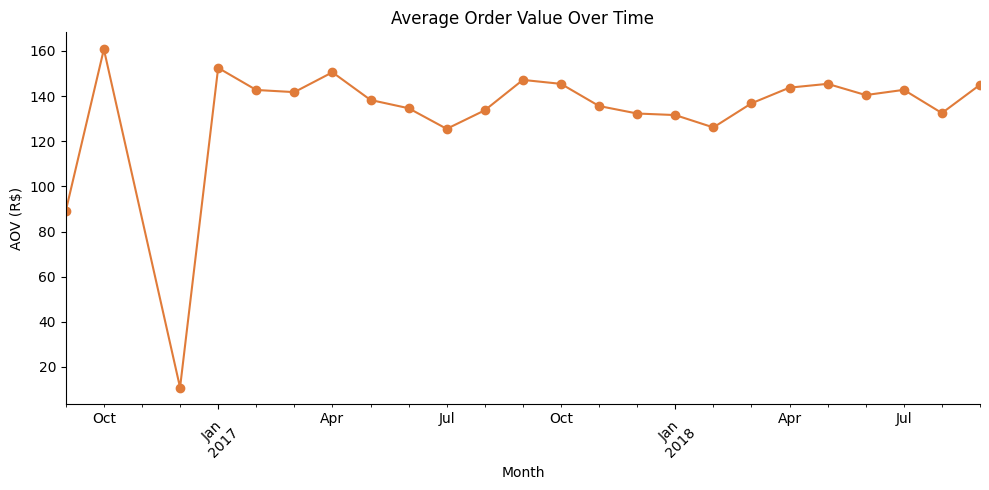

In [ ]:
# --- Chart 10: Average Order Value Over Time ---
monthly_aov = (
    master.drop_duplicates("order_id")
    .groupby("order_year_month")
    .apply(lambda g: master.loc[master['order_id'].isin(g['order_id']), 'item_revenue'].sum() / len(g))
)

fig, ax = plt.subplots()
monthly_aov.plot(kind="line", marker="o", ax=ax, color="#E07B39")
ax.set_title("Average Order Value Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("AOV (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight: a rising AOV trend suggests successful upsell/premiumization; a flat or falling
# trend alongside rising order volume suggests growth is coming from lower-value baskets.


## 10. Key Insights & Recommendations Summary

*(Fill in with your actual numeric findings once you run this against the full dataset — this
section is where you translate charts into decisions.)*

| Finding | Business Impact | Recommendation |
|---|---|---|
| Top categories concentrate X% of revenue | Catalog is [diversified / concentrated] | [Expand adjacent categories / protect top-category supply] |
| Top 10 sellers = X% of revenue | [Low / High] seller concentration risk | [Recruit more sellers in top categories / build seller success programs] |
| X% of orders use installments | Customers are [price-sensitive / cash-flow constrained] | [Consider promoting installment options more prominently in marketing] |
| Order volume trend is [up/down/flat] | Marketplace is [growing / plateauing] | [Investment thesis for next planning cycle] |
| AOV trend is [rising/falling] | [Premiumization is/isn't working] | [Bundle/upsell strategy] |

**Next step:** hand off the top customers, sellers, and categories lists to the SQL retention
and YoY growth analysis (Advanced Questions 3-5) to connect this EDA to the deeper trend queries.
